In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Copy Datasets from Drive

In [ ]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/ffpp_cropped_faces /content/
!cp -r /content/drive/MyDrive/DL_Project/datasets/celebv2_cropped_faces /content/
!cp /content/drive/MyDrive/DL_Project/datasets/compressed_ffpp_celebv2.zip /content/
!unzip -q /content/compressed_ffpp_celebv2.zip -d /content/

In [ ]:
!pip install -q timm torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.7 MB/s eta 0:00:00


## Imports

In [ ]:
import os
import random
import io
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import timm
import gc
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda



# JPEG compression

In [ ]:
class FastJPEGSimulation(nn.Module):
    def __init__(self, quality_range=(30, 90), p=0.8):
        super().__init__()
        self.quality_range = quality_range
        self.p = p

    def forward(self, x):
        if not self.training or random.random() > self.p:
            return x

        quality = random.randint(self.quality_range[0], self.quality_range[1])
        strength = 1.0 - (quality - 30) / 60.0

        with torch.cuda.amp.autocast():
            # add quantization noise
            noise_scale = 0.05 * strength
            noise = torch.randn_like(x) * noise_scale

            # simulate quantization
            if strength > 0.3:
                quant_levels = int(20 * (1 - strength) + 5)
                x = torch.round(x * quant_levels) / quant_levels

            # optional blur for very high compression
            if strength > 0.7 and random.random() < 0.2:
                x = F.avg_pool2d(x, kernel_size=3, stride=1, padding=1)

            return torch.clamp(x + noise, 0, 1)

# DATASET CLASS

In [ ]:
class FastDeepfakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []

        for label_name, label in [('real', 0), ('fake', 1)]:
            class_dir = os.path.join(root_dir, label_name)
            if os.path.exists(class_dir):
                for img in os.listdir(class_dir):
                    if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(class_dir, img), label))

        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='black')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# VIT MODEL WITH CONSISTENCY

In [ ]:
class ViTWithConsistency(nn.Module):
    def __init__(self, model_name='vit_base_patch16_224', pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.norm = nn.LayerNorm(768)
        self.classifier = nn.Linear(768, 1)

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        features = self.norm(features)
        logits = self.classifier(features).squeeze(1)

        if return_embedding:
            return logits, features
        return logits

## CONSISTENCY LOSS

In [ ]:
def fast_consistency_loss(emb1, emb2):
    emb1_norm = F.normalize(emb1, p=2, dim=-1)
    emb2_norm = F.normalize(emb2, p=2, dim=-1)
    similarity = (emb1_norm * emb2_norm).sum(dim=-1)
    return (1 - similarity).mean()


## TRAINING CONFIGURATION

In [ ]:
class Config:
    model_name = 'vit_base_patch16_224'
    img_size = 224
    batch_size = 32
    learning_rate = 5e-5
    weight_decay = 1e-4
    max_epochs = 20
    patience = 5
    lambda_cons = 1.5
    num_workers = 2
    ffpp_root = '/content/ffpp_cropped_faces'
    save_dir = '/content/drive/MyDrive/DL_Project/checkpoints'  # will use /content if this fails
    seed = 42

config = Config()

# SETUP
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scaler = torch.cuda.amp.GradScaler()
print(f"Using device: {device}")

## DATA TRANSFORMS

In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((config.img_size, config.img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize((config.img_size, config.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


### LOAD DATASETS

In [ ]:
print("LOADING DATASETS")
train_ds = FastDeepfakeDataset(os.path.join(config.ffpp_root, 'train'), transform=train_transform)
val_ds = FastDeepfakeDataset(os.path.join(config.ffpp_root, 'val'), transform=test_transform)
test_ds = FastDeepfakeDataset(os.path.join(config.ffpp_root, 'test'), transform=test_transform)

print(f"\nTrain: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

train_loader = DataLoader(
    train_ds,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True,
    persistent_workers=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

### Traning Setup

In [ ]:
print("INITIALIZING MODEL")
model = ViTWithConsistency(model_name=config.model_name, pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# TRAINING SETUP
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
jpeg_aug = FastJPEGSimulation(quality_range=(30, 90), p=0.8)


save_dir = '/content/checkpoints'
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, 'best_vit_consistency.pth')

def train_epoch(model, loader, optimizer, criterion, jpeg_aug, lambda_cons, device, scaler):
    model.train()
    jpeg_aug.train()

    total_loss = 0
    pbar = tqdm(loader, desc="Training")

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            # Forward original
            outputs_orig, emb_orig = model(images, return_embedding=True)
            loss_cls = criterion(outputs_orig, labels)

            # Forward compressed
            images_comp = jpeg_aug(images)
            outputs_comp, emb_comp = model(images_comp, return_embedding=True)
            loss_cons = fast_consistency_loss(emb_orig, emb_comp)

            # Combined loss
            loss = loss_cls + lambda_cons * loss_cons

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}')

    return total_loss / len(loader.dataset)

## EVALUATION FUNCTION

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []

    for images, labels in tqdm(loader, desc="Validating", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():
            outputs = model(images)
            probs = torch.sigmoid(outputs)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return {'auc': roc_auc_score(all_labels, all_probs)}

## TRAINING

In [ ]:
print("STARTING TRAINING")
print(f"Batch size: {config.batch_size}")
print(f"Learning rate: {config.learning_rate}")
print(f"Max epochs: {config.max_epochs}")

history = {'train_loss': [], 'val_auc': []}
best_auc = 0.0
patience_counter = 0
start_time = time.time()

for epoch in range(config.max_epochs):
    print(f"\nEpoch [{epoch+1}/{config.max_epochs}]")

    # Training
    train_loss = train_epoch(
        model, train_loader, optimizer, criterion, jpeg_aug,
        config.lambda_cons, device, scaler
    )

    # Validation
    val_metrics = evaluate(model, val_loader)
    current_auc = val_metrics['auc']

    # Update scheduler
    scheduler.step(current_auc)

    # History
    history['train_loss'].append(train_loss)
    history['val_auc'].append(current_auc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val AUC: {current_auc:.4f}")

    # Save best model
    if current_auc > best_auc:
        best_auc = current_auc
        patience_counter = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'best_auc': best_auc,
        }, best_model_path)
        print(f"✓ Best model saved (AUC={best_auc:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{config.patience})")

    if patience_counter >= config.patience:
        print("Early stopping triggered!")
        break

total_time = time.time() - start_time
print(f"\nTraining complete! Time: {total_time/60:.1f} minutes")
print(f"Best Validation AUC: {best_auc:.4f}")


# FINAL TEST EVALUATION
print("FINAL TEST EVALUATION")
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")

test_loader = DataLoader(test_ds, batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)

model.eval()
all_labels = []
all_probs = []

for images, labels in tqdm(test_loader, desc="Testing"):
    images = images.to(device, non_blocking=True)
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model(images)
            probs = torch.sigmoid(outputs)
    all_labels.extend(labels.numpy())
    all_probs.extend(probs.cpu().numpy())

auc = roc_auc_score(all_labels, all_probs)
preds = [1 if p >= 0.5 else 0 for p in all_probs]
acc = accuracy_score(all_labels, preds)
f1 = f1_score(all_labels, preds)

print(f"\nTest Results:")
print(f"  AUC: {auc:.4f}")
print(f"  Accuracy: {acc:.4f}")
print(f"  F1 Score: {f1:.4f}")

# Save results locally
results_df = pd.DataFrame([{
    'Model': 'ViT Consistency',
    'Test AUC': auc,
    'Test Accuracy': acc,
    'Test F1': f1,
    'Best Val AUC': best_auc,
    'Training Time (min)': total_time/60,
    'Batch Size': config.batch_size
}])
results_df.to_csv('/content/final_results.csv', index=False)
print("\nResults saved to /content/final_results.csv")
print("ALL DONE!")

Using device: cuda

LOADING DATASETS
Loaded 14369 samples
Loaded 2380 samples
Loaded 2388 samples

Train: 14369, Val: 2380, Test: 2388
Train batches: 450
Validation batches: 75

INITIALIZING MODEL


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total parameters: 85,800,961

STARTING TRAINING
Batch size: 32
Learning rate: 5e-05
Max epochs: 20

Epoch [1/20]


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Validating:   0%|          | 0/75 [00:00<?, ?it/s]

...

Training:   0%|          | 0/450 [00:00<?, ?it/s]

Validating:   0%|          | 0/75 [00:00<?, ?it/s]

Train Loss: 0.0052
Val AUC: 0.9079
No improvement (1/5)

Training complete! Time: 91.7 minutes
Best Validation AUC: 0.9109

FINAL TEST EVALUATION
Loaded best model from epoch 19


Testing:   0%|          | 0/75 [00:00<?, ?it/s]


Test Results:
  AUC: 0.8824
  Accuracy: 0.7919
  F1 Score: 0.7984

Results saved to /content/final_results.csv

ALL DONE!


# EVALUATIONS

### Configration

In [ ]:
class Config:
    img_size = 224
    batch_size = 64
    num_workers = 0
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ffpp_root = '/content/ffpp_cropped_faces'
    celeb_root = '/content/celebv2_cropped_faces'
    compressed_root = '/content/compressed_ffpp_celebv2'
    baseline_path = '/content/drive/MyDrive/DL_Project/checkpoints/best_vit_b16.pth'
    consistency_path = '/content/drive/MyDrive/dl_outputs/best_vit_consistency.pth'
    output_dir = '/content/drive/MyDrive/dl_outputs'

config = Config()
print(f"Using device: {config.device}")

os.makedirs(config.output_dir, exist_ok=True)

## Dataset

In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []
        for label_name, label in [('real', 0), ('fake', 1)]:
            class_dir = os.path.join(root_dir, label_name)
            if os.path.exists(class_dir):
                for img in os.listdir(class_dir):
                    if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(class_dir, img), label))
        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color='black')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

## ViT With Consistency

In [ ]:
class ViTWithConsistency(nn.Module):
    def __init__(self, model_name='vit_base_patch16_224', pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.norm = nn.LayerNorm(768)
        self.classifier = nn.Linear(768, 1)

    def forward(self, x):
        features = self.backbone(x)
        features = self.norm(features)
        logits = self.classifier(features).squeeze(1)
        return logits


COMPRESSION ROBUSTNESS EVALUATION

Using device: cuda

LOADING MODELS
Loading Baseline ViT...
Baseline loaded
Loading Consistency Model...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Consistency model loaded

RUNNING COMPRESSION ROBUSTNESS EVALUATION
Evaluating: FF++ Clean
Loaded 2388 samples


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  Baseline AUC: 0.7711
  Consistency AUC: 0.7935
  Improvement: +0.0224
Evaluating: Celeb-DF Q10
Loaded 5990 samples


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

  Baseline AUC: 0.6904
  Consistency AUC: 0.7174
  Improvement: +0.0270

Results saved to /content/drive/MyDrive/dl_outputs/compression_robustness_results.csv

COMPRESSION ROBUSTNESS SUMMARY
Dataset              Quality  Baseline   Consistency  Improvement 
----------------------------------------------------------------------
FF++ Clean           Clean    0.8839     0.8889       +0.0050
FF++ Q90             Q90      0.8843     0.8880       +0.0037
FF++ Q70             Q70      0.8808     0.8840       +0.0032
FF++ Q50             Q50      0.8734     0.8807       +0.0073
FF++ Q30             Q30      0.8705     0.8740       +0.0035
FF++ Q10             Q10      0.8135     0.8192       +0.0056
Celeb-DF Clean       Clean    0.7765     0.8000       +0.0235
Celeb-DF Q90         Q90      0.7766     0.8003       +0.0237
Celeb-DF Q70         Q70      0.7754     0.7990       +0.0236
Celeb-DF Q50         Q50      0.7743     0.7964       +0.0221
Celeb-DF Q30         Q30      0.7711     0.7935    

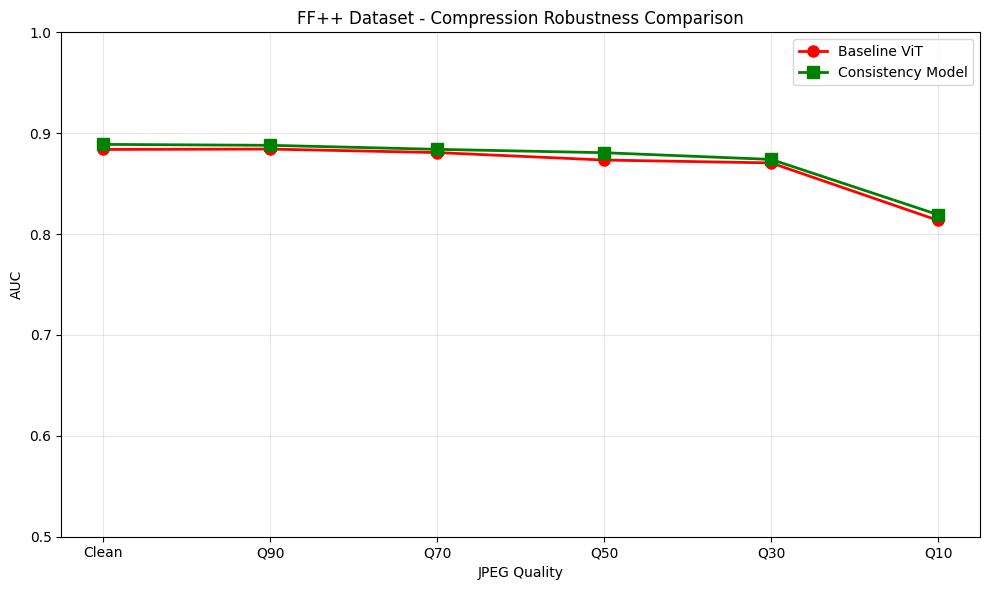

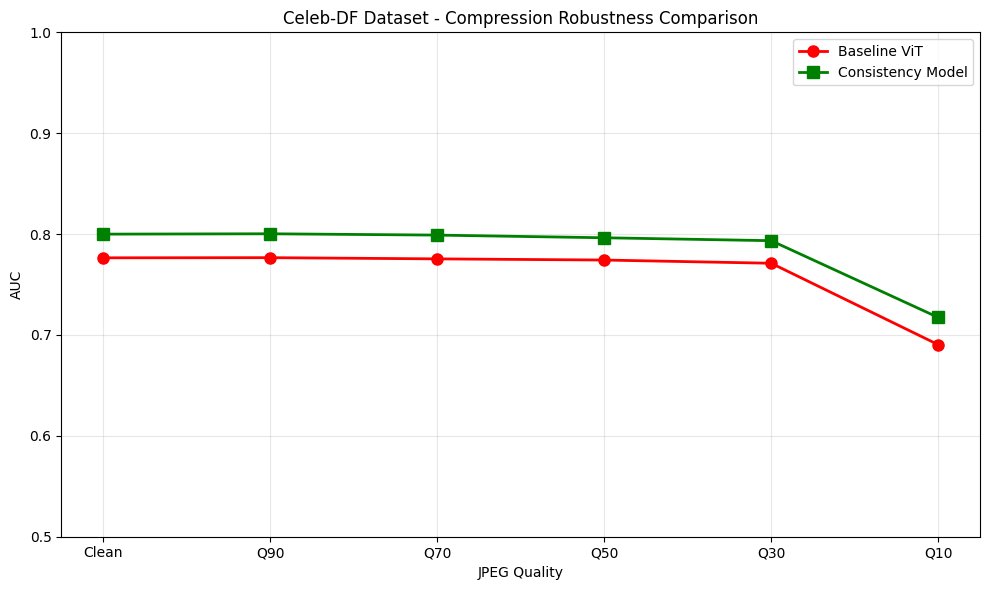

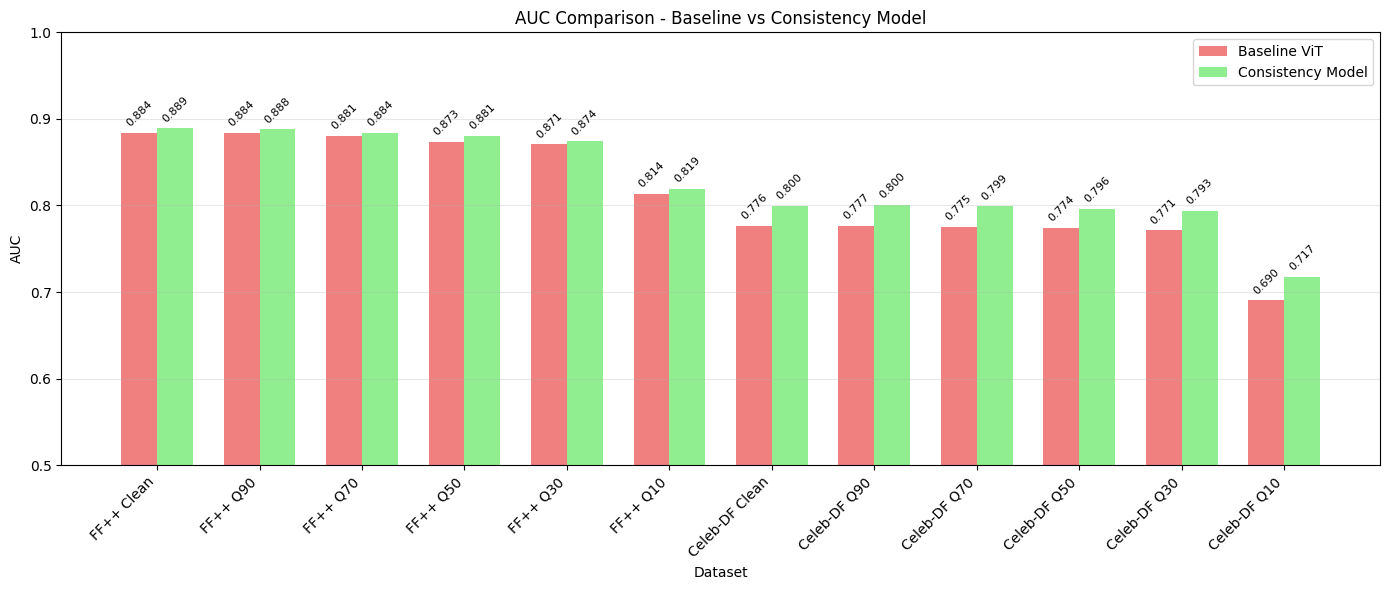


FINAL SUMMARY STATISTICS
FF++:      Baseline: 0.8677 -> Consistency: 0.8725 (+0.0047)
Celeb-DF:  Baseline: 0.7607 -> Consistency: 0.7844 (+0.0237)
Best Improvement: Celeb-DF Q10 at Q10
   Baseline: 0.6904 -> Consistency: 0.7174 (+0.0270)

ALL EVALUATIONS COMPLETE!


In [ ]:

@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []
    for images, labels in tqdm(loader, desc="Evaluating", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    preds = [1 if p >= 0.5 else 0 for p in all_probs]
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)
    return {'auc': auc, 'accuracy': acc, 'f1': f1}

print("\nLOADING MODELS")
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

print("Loading Baseline ViT...")
baseline_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=1).to(config.device)
checkpoint = torch.load(config.baseline_path, map_location=config.device, weights_only=False)
baseline_model.load_state_dict(checkpoint['model_state_dict'])
baseline_model.eval()
print("Baseline loaded")

print("Loading Consistency Model...")
consistency_model = ViTWithConsistency().to(config.device)
checkpoint = torch.load(config.consistency_path, map_location=config.device, weights_only=False)
consistency_model.load_state_dict(checkpoint['model_state_dict'])
consistency_model.eval()
print("Consistency model loaded")

dataset_variants = [
    ('FF++ Clean', os.path.join(config.ffpp_root, 'test'), 'Clean'),
    ('FF++ Q90', os.path.join(config.compressed_root, 'ffpp/q90'), 'Q90'),
    ('FF++ Q70', os.path.join(config.compressed_root, 'ffpp/q70'), 'Q70'),
    ('FF++ Q50', os.path.join(config.compressed_root, 'ffpp/q50'), 'Q50'),
    ('FF++ Q30', os.path.join(config.compressed_root, 'ffpp/q30'), 'Q30'),
    ('FF++ Q10', os.path.join(config.compressed_root, 'ffpp/q10'), 'Q10'),
    ('Celeb-DF Clean', config.celeb_root, 'Clean'),
    ('Celeb-DF Q90', os.path.join(config.compressed_root, 'celebv2/q90'), 'Q90'),
    ('Celeb-DF Q70', os.path.join(config.compressed_root, 'celebv2/q70'), 'Q70'),
    ('Celeb-DF Q50', os.path.join(config.compressed_root, 'celebv2/q50'), 'Q50'),
    ('Celeb-DF Q30', os.path.join(config.compressed_root, 'celebv2/q30'), 'Q30'),
    ('Celeb-DF Q10', os.path.join(config.compressed_root, 'celebv2/q10'), 'Q10'),
]

print("\nRUNNING COMPRESSION ROBUSTNESS EVALUATION")
results = []

for dataset_name, dataset_path, quality in dataset_variants:
    if not os.path.exists(dataset_path):
        print(f"Skipping {dataset_name} - Path not found")
        continue
    print(f"Evaluating: {dataset_name}")
    dataset = DeepfakeDataset(dataset_path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=config.batch_size, shuffle=False, num_workers=0)
    baseline_metrics = evaluate_model(baseline_model, loader, config.device)
    consistency_metrics = evaluate_model(consistency_model, loader, config.device)
    results.append({
        'Dataset': dataset_name,
        'Quality': quality,
        'Baseline_AUC': baseline_metrics['auc'],
        'Baseline_Acc': baseline_metrics['accuracy'],
        'Baseline_F1': baseline_metrics['f1'],
        'Consistency_AUC': consistency_metrics['auc'],
        'Consistency_Acc': consistency_metrics['accuracy'],
        'Consistency_F1': consistency_metrics['f1'],
        'Improvement_AUC': consistency_metrics['auc'] - baseline_metrics['auc']
    })
    print(f"  Baseline AUC: {baseline_metrics['auc']:.4f}")
    print(f"  Consistency AUC: {consistency_metrics['auc']:.4f}")
    print(f"  Improvement: +{consistency_metrics['auc'] - baseline_metrics['auc']:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(config.output_dir, 'compression_robustness_results.csv'), index=False)
print(f"\nResults saved to {config.output_dir}/compression_robustness_results.csv")

print("\nCOMPRESSION ROBUSTNESS SUMMARY")
print(f"{'Dataset':<20} {'Quality':<8} {'Baseline':<10} {'Consistency':<12} {'Improvement':<12}")
print("-" * 70)
for _, row in results_df.iterrows():
    print(f"{row['Dataset']:<20} {row['Quality']:<8} {row['Baseline_AUC']:.4f}     {row['Consistency_AUC']:.4f}       +{row['Improvement_AUC']:.4f}")

print("\nGENERATING PLOTS")
quality_order = ['Clean', 'Q90', 'Q70', 'Q50', 'Q30', 'Q10']

plt.figure(figsize=(10, 6))
ffpp_data = results_df[results_df['Dataset'].str.contains('FF++')].copy()
ffpp_data['Quality'] = pd.Categorical(ffpp_data['Quality'], categories=quality_order, ordered=True)
ffpp_data = ffpp_data.sort_values('Quality')
plt.plot(ffpp_data['Quality'], ffpp_data['Baseline_AUC'], 'o-', label='Baseline ViT', linewidth=2, markersize=8, color='red')
plt.plot(ffpp_data['Quality'], ffpp_data['Consistency_AUC'], 's-', label='Consistency Model', linewidth=2, markersize=8, color='green')
plt.xlabel('JPEG Quality')
plt.ylabel('AUC')
plt.title('FF++ Dataset - Compression Robustness Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(config.output_dir, 'ffpp_robustness_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
celeb_data = results_df[results_df['Dataset'].str.contains('Celeb-DF')].copy()
celeb_data['Quality'] = pd.Categorical(celeb_data['Quality'], categories=quality_order, ordered=True)
celeb_data = celeb_data.sort_values('Quality')
plt.plot(celeb_data['Quality'], celeb_data['Baseline_AUC'], 'o-', label='Baseline ViT', linewidth=2, markersize=8, color='red')
plt.plot(celeb_data['Quality'], celeb_data['Consistency_AUC'], 's-', label='Consistency Model', linewidth=2, markersize=8, color='green')
plt.xlabel('JPEG Quality')
plt.ylabel('AUC')
plt.title('Celeb-DF Dataset - Compression Robustness Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(config.output_dir, 'celeb_robustness_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.35
bars1 = plt.bar(x - width/2, results_df['Baseline_AUC'], width, label='Baseline ViT', color='lightcoral')
bars2 = plt.bar(x + width/2, results_df['Consistency_AUC'], width, label='Consistency Model', color='lightgreen')
plt.xlabel('Dataset')
plt.ylabel('AUC')
plt.title('AUC Comparison - Baseline vs Consistency Model')
plt.xticks(x, results_df['Dataset'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0.5, 1.0)
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005, f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=45)
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005, f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(config.output_dir, 'auc_comparison_barchart.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nFINAL SUMMARY STATISTICS")
avg_baseline_ffpp = results_df[results_df['Dataset'].str.contains('FF++')]['Baseline_AUC'].mean()
avg_consistency_ffpp = results_df[results_df['Dataset'].str.contains('FF++')]['Consistency_AUC'].mean()
avg_baseline_celeb = results_df[results_df['Dataset'].str.contains('Celeb-DF')]['Baseline_AUC'].mean()
avg_consistency_celeb = results_df[results_df['Dataset'].str.contains('Celeb-DF')]['Consistency_AUC'].mean()
print(f"FF++:      Baseline: {avg_baseline_ffpp:.4f} -> Consistency: {avg_consistency_ffpp:.4f} (+{avg_consistency_ffpp - avg_baseline_ffpp:.4f})")
print(f"Celeb-DF:  Baseline: {avg_baseline_celeb:.4f} -> Consistency: {avg_consistency_celeb:.4f} (+{avg_consistency_celeb - avg_baseline_celeb:.4f})")

best_improvement = results_df.loc[results_df['Improvement_AUC'].idxmax()]
print(f"Best Improvement: {best_improvement['Dataset']} at {best_improvement['Quality']}")
print(f"   Baseline: {best_improvement['Baseline_AUC']:.4f} -> Consistency: {best_improvement['Consistency_AUC']:.4f} (+{best_improvement['Improvement_AUC']:.4f})")

print("\nALL EVALUATIONS COMPLETE!")